In [20]:
import pickle
from pathlib import Path

MODEL_PATH = Path("../models/som_model_200Hz_ver8_ppg.pkl")  

with open(MODEL_PATH, "rb") as f:
    som_model = pickle.load(f)

print("Modell laddad")
print(som_model.get_summary())

Modell laddad
{'x': 30, 'y': 30, 'input_len': 3, 'sigma': 6, 'learning_rate': 0.1, 'decay_function': 'asymptotic_decay', 'neighborhood_function': 'gaussian', 'topology': 'rectangular', 'activation_distance': 'euclidean', 'sigma_decay_function': 'asymptotic_decay', 'random_seed': 42}


In [21]:
import pandas as pd

df_test = pd.read_csv("test_features_IQTest_8/IQTEST_8_ALLPARTICIPANTS_WINDOWS.csv")

print("Rows:", len(df_test))
df_test.head()

Rows: 3253


,HR,HRV_RMSSD,HRV_SDNN,RR_mean,RR_std,RR_min,RR_max,RR_count,RR_diff_std,RR_valid,SCR_Rate,participant,time_sec,EDA_Tonic_log,EDA_Phasic_log
0,74.586494,28.037673,21.863280,805.675676,21.565806,760.0,850.0,37,28.032168,1,0.064539,49,0,6.0,0.679980
1,74.481649,27.959913,21.566085,805.657895,21.280429,760.0,850.0,38,27.959587,1,0.032790,49,1,6.0,-0.079550
2,74.545233,28.625940,22.551243,804.324324,22.244409,760.0,850.0,37,28.620549,1,0.032790,49,2,6.0,-3.172177
3,74.654259,28.198207,22.947256,803.918919,22.635034,760.0,850.0,37,28.195129,1,0.032790,49,3,6.0,-1.173717
4,74.610308,28.080483,23.018948,803.421053,22.714048,755.0,850.0,38,28.064545,1,0.032790,49,4,6.0,-1.160405


In [22]:
features = [
    "HR",
    "HRV_RMSSD",
    "HRV_SDNN"
]

# Kontroll att features finns
missing = [f for f in features if f not in df_test.columns]
assert len(missing) == 0, f"Saknade features: {missing}"

df_test[features].describe()

,HR,HRV_RMSSD,HRV_SDNN
count,3253.000000,3253.000000,3253.000000
mean,85.063110,54.497827,53.409327
std,11.762778,21.522868,22.821185
min,63.827343,10.606602,10.061556
25%,76.642375,38.220555,37.041848
50%,81.878456,55.501400,51.140404
75%,93.009321,70.246818,65.956086
max,114.100160,116.390460,160.382683


In [23]:
df_test_clean = df_test.dropna(subset=features).copy()

print("Före:", len(df_test))
print("Efter:", len(df_test_clean))

Före: 3253
Efter: 3253


In [24]:
print(df_test_clean[features].describe())

                HR    HRV_RMSSD     HRV_SDNN
count  3253.000000  3253.000000  3253.000000
mean     85.063110    54.497827    53.409327
std      11.762778    21.522868    22.821185
min      63.827343    10.606602    10.061556
25%      76.642375    38.220555    37.041848
50%      81.878456    55.501400    51.140404
75%      93.009321    70.246818    65.956086
max     114.100160   116.390460   160.382683


In [25]:
import numpy as np

X_test = df_test_clean[features]

print("Har NaN:\n", X_test.isna().sum())

# 🔒 Feature consistency (viktigt!)
assert list(X_test.columns) == list(som_model.scaler.feature_names_in_)

Har NaN:
 HR           0
HRV_RMSSD    0
HRV_SDNN     0
dtype: int64


In [26]:
X_test_scaled = pd.DataFrame(
    som_model.scaler.transform(X_test),
    columns=features,
    index=X_test.index
)

print("Shape:", X_test_scaled.shape)

Shape: (3253, 3)


In [27]:
print(X_test_scaled.describe())
print("\nVariance:\n", X_test_scaled.var())

                HR    HRV_RMSSD     HRV_SDNN
count  3253.000000  3253.000000  3253.000000
mean      0.366361     0.377678     0.229162
std       0.132734     0.170541     0.120004
min       0.126732     0.029896     0.001220
25%       0.271339     0.248701     0.143094
50%       0.330424     0.385630     0.217231
75%       0.456027     0.502468     0.295138
max       0.694021     0.868097     0.791675

Variance:
 HR           0.017618
HRV_RMSSD    0.029084
HRV_SDNN     0.014401
dtype: float64


In function predict_cluster send df **WITHOUT** scaling

In [28]:
pred_clusters = som_model.predict_cluster(X_test)

# Säkerhet
assert len(pred_clusters) == len(df_test_clean)

df_test_clean["cluster"] = pred_clusters

print("Clusters tilldelade ✅")

🔍 INPUT (first 5 rows):
          HR  HRV_RMSSD   HRV_SDNN
0  74.586494  28.037673  21.863280
1  74.481649  27.959913  21.566085
2  74.545233  28.625940  22.551243
3  74.654259  28.198207  22.947256
4  74.610308  28.080483  23.018948
🔍 INPUT range:
min: HR           63.827343
HRV_RMSSD    10.606602
HRV_SDNN     10.061556
dtype: float64
max: HR           114.100160
HRV_RMSSD    116.390460
HRV_SDNN     160.382683
dtype: float64

🔍 AFTER scaling (first 5 rows):
[[0.24814024 0.16801496 0.06327879]
 [0.24695714 0.16739881 0.06171601]
 [0.24767464 0.17267622 0.0668964 ]
 [0.24890491 0.16928698 0.06897882]
 [0.24840895 0.16835417 0.0693558 ]]
🔍 AFTER scaling range:
min: 0.0012201404474271732
max: 0.8680970039850023

🔍 Unique BMUs: 345
🔍 Unique clusters: {np.int32(0), np.int32(1), np.int32(2)}
Clusters tilldelade ✅


In [29]:
bmus = [som_model.som.winner(x) for x in X_test_scaled.values]

print("Unika BMUs:", len(set(bmus)))

Unika BMUs: 345


=== Cluster Distribution ===
cluster
1    0.553643
2    0.377498
0    0.068860
Name: proportion, dtype: float64

=== Per Participant ===
participant  cluster
49           1          1.000000
50           1          0.605166
             2          0.394834
51           1          0.933824
             0          0.066176
52           1          1.000000
53           2          0.656827
             1          0.343173
54           2          0.845018
             0          0.154982
55           2          0.660517
             0          0.254613
             1          0.084871
56           1          1.000000
57           1          0.885609
             2          0.114391
58           2          0.782288
             1          0.217712
59           2          0.446494
             0          0.350554
             1          0.202952
60           2          0.630996
             1          0.369004
Name: proportion, dtype: float64

=== Cluster Means ===
                HR  HRV_RMS

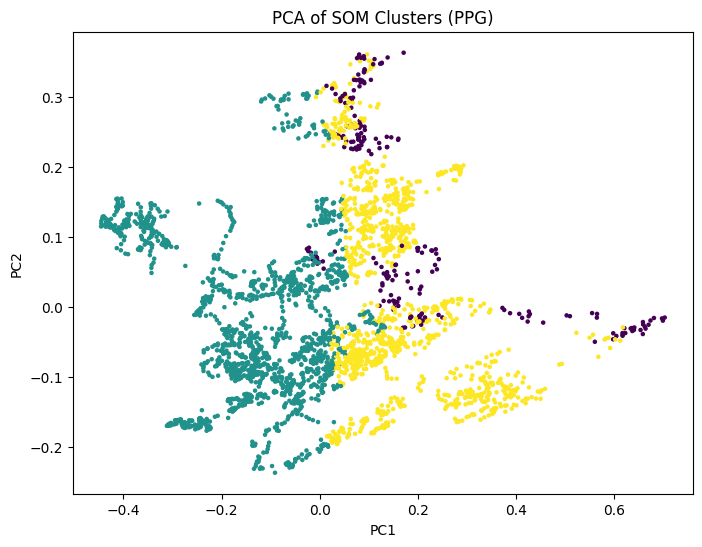


=== Cluster Interpretation ===

Cluster 0
HR           92.644099
HRV_RMSSD    70.895295
HRV_SDNN     95.011714
Name: 0, dtype: float64

Cluster 1
HR           85.717937
HRV_RMSSD    39.442642
HRV_SDNN     41.460927
Name: 1, dtype: float64

Cluster 2
HR           82.719882
HRV_RMSSD    73.586878
HRV_SDNN     63.344289
Name: 2, dtype: float64

Silhouette (neurons): 0.47607541952404403


In [30]:


import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# 1. Klusterfördelning
print("=== Cluster Distribution ===")
print(df_test_clean["cluster"].value_counts(normalize=True))

# 2. Per participant
print("\n=== Per Participant ===")
print(df_test_clean.groupby("participant")["cluster"].value_counts(normalize=True))

# 3. Kluster means
print("\n=== Cluster Means ===")
cluster_means = df_test_clean.groupby("cluster")[features].mean()
print(cluster_means)

# 4. Kluster std
print("\n=== Cluster STD ===")
print(df_test_clean.groupby("cluster")[features].std())

# 5. Label mapping
cluster_labels = {
    0: "Active / Engagement",
    1: "Stress",
    2: "Recovery"
}

df_test_clean["cluster_label"] = df_test_clean["cluster"].map(cluster_labels)

print("\n=== Cluster Labels Distribution ===")
print(df_test_clean["cluster_label"].value_counts(normalize=True))

# 6. PCA visualisering
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_test_scaled)

plt.figure(figsize=(8,6))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df_test_clean["cluster"],
    s=5
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of SOM Clusters (PPG)")
plt.show()

# 7. Fysiologisk tolkning
print("\n=== Cluster Interpretation ===")
for c in sorted(df_test_clean["cluster"].unique()):
    print(f"\nCluster {c}")
    print(cluster_means.loc[c])

# 8. Silhouette (på neuroner - snabbt)
try:
    weights = som_model.som.get_weights().reshape(-1, len(features))
    labels = som_model.kmeans.labels_
    score = silhouette_score(weights, labels)
    print("\nSilhouette (neurons):", score)
except:
    print("\nSilhouette kunde inte beräknas (saknar kmeans i modellen)")

In [31]:
bmus = [som_model.som.winner(x) for x in X_test_scaled.values]

cluster_labels = []

for bmu in bmus:
    idx = bmu[0] * som_model.som._weights.shape[1] + bmu[1]
    cluster_labels.append(som_model.kmeans.labels_[idx])

print(set(cluster_labels))

{np.int32(0), np.int32(1), np.int32(2)}


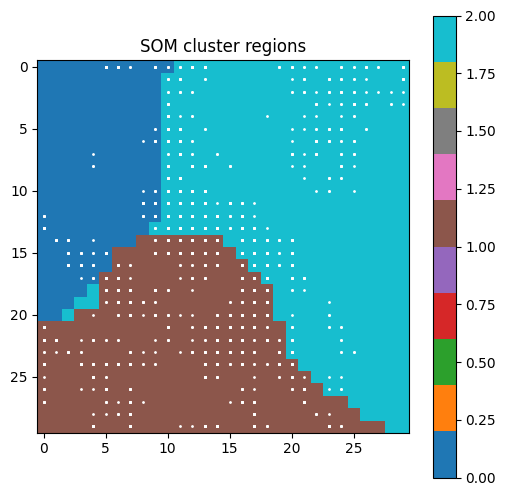

In [32]:
import matplotlib.pyplot as plt
import numpy as np

# k-means labels över SOM grid
labels_map = som_model.kmeans.labels_.reshape(30, 30)

plt.figure(figsize=(6,6))
plt.imshow(labels_map, cmap='tab10')
plt.title("SOM cluster regions")
plt.colorbar()

# overlay dina BMUs
bmus = [som_model.som.winner(x) for x in X_test_scaled.values]
xs = [b[0] for b in bmus]
ys = [b[1] for b in bmus]

plt.scatter(ys, xs, s=1, c='white')  # overlay
plt.show()

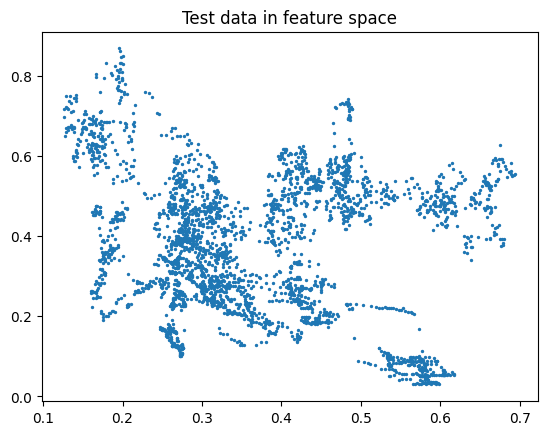

In [33]:
import matplotlib.pyplot as plt

plt.scatter(
    X_test_scaled["HR"],
    X_test_scaled["HRV_RMSSD"],
    s=2
)
plt.title("Test data in feature space")
plt.show()